In [46]:
import numpy as np
import pandas as pd

In [47]:
import yfinance as yf
from datetime import datetime, timedelta

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN"]

end = datetime.today()
start = end - timedelta(days=365 * 3)

data = {}

for ticker in tickers:
    df = yf.Ticker(ticker).history(start=start, end=end, auto_adjust=True)
    df = df.reset_index()
    data[ticker] = df

In [48]:
last_price = data[ticker]["Close"].iloc[-1]
print(f"{ticker} last price: {last_price:.2f}")

AMZN last price: 200.95


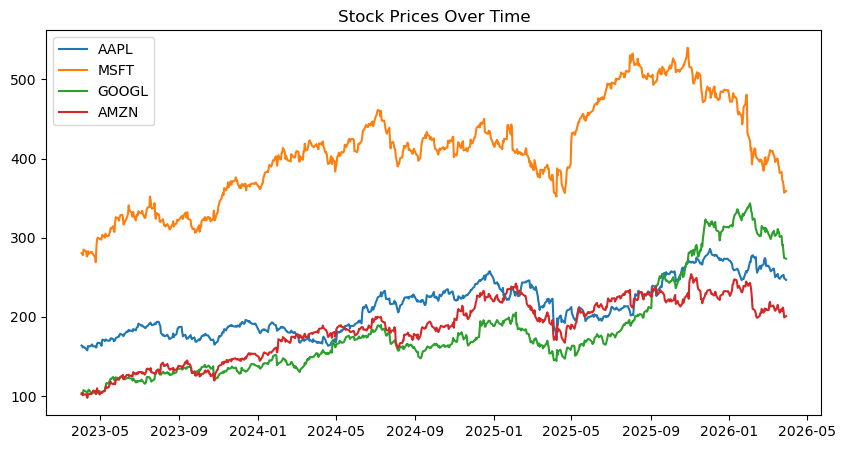

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for ticker in tickers:
    plt.plot(data[ticker]["Date"], data[ticker]["Close"], label=ticker)

plt.legend()
plt.title("Stock Prices Over Time")
plt.show()

## Computing Returns

In [50]:
returns = pd.DataFrame()

for ticker in tickers:
    returns[ticker] = data[ticker]["Close"].pct_change()

returns = returns.dropna()
returns.head()

,AAPL,MSFT,GOOGL,AMZN
1,-0.003250,-0.000174,0.003450,0.015038
2,-0.011290,-0.009889,-0.002387,-0.027417
3,0.005496,0.025533,0.037810,0.009496
4,-0.015972,-0.007579,-0.018262,0.001078
5,-0.007591,-0.022668,-0.010241,-0.022022


In [51]:
cov_matrix = returns.cov()

cov_matrix

,AAPL,MSFT,GOOGL,AMZN
AAPL,0.000262,0.000104,0.000127,0.000141
MSFT,0.000104,0.000219,0.000114,0.000165
GOOGL,0.000127,0.000114,0.000334,0.000195
AMZN,0.000141,0.000165,0.000195,0.000388


## Forecasting Prices (Prophet)
We predict future prices, estimate returns

In [52]:
from prophet import Prophet

forecasts = {}

for ticker in tickers:
    df = data[ticker][["Date", "Close"]].copy()
    df = df.dropna().drop_duplicates(subset="Date").sort_values("Date")
    df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)
    df.columns = ["ds", "y"]

    # remove timezone
    df["ds"] = pd.to_datetime(df["ds"]).dt.tz_localize(None)

    model = Prophet(daily_seasonality=True)
    model.fit(df)

    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)

    forecasts[ticker] = forecast

12:02:16 - cmdstanpy - INFO - Chain [1] start processing
12:02:16 - cmdstanpy - INFO - Chain [1] done processing
12:02:17 - cmdstanpy - INFO - Chain [1] start processing
12:02:18 - cmdstanpy - INFO - Chain [1] done processing
12:02:18 - cmdstanpy - INFO - Chain [1] start processing
12:02:19 - cmdstanpy - INFO - Chain [1] done processing
12:02:19 - cmdstanpy - INFO - Chain [1] start processing
12:02:20 - cmdstanpy - INFO - Chain [1] done processing


In [53]:
print("Last actual price:", df["y"].iloc[-1])
print("Last forecasted price:", forecasts[ticker]["yhat"].iloc[len(df)-1])

Last actual price: 200.9499969482422
Last forecasted price: 199.6541061158886


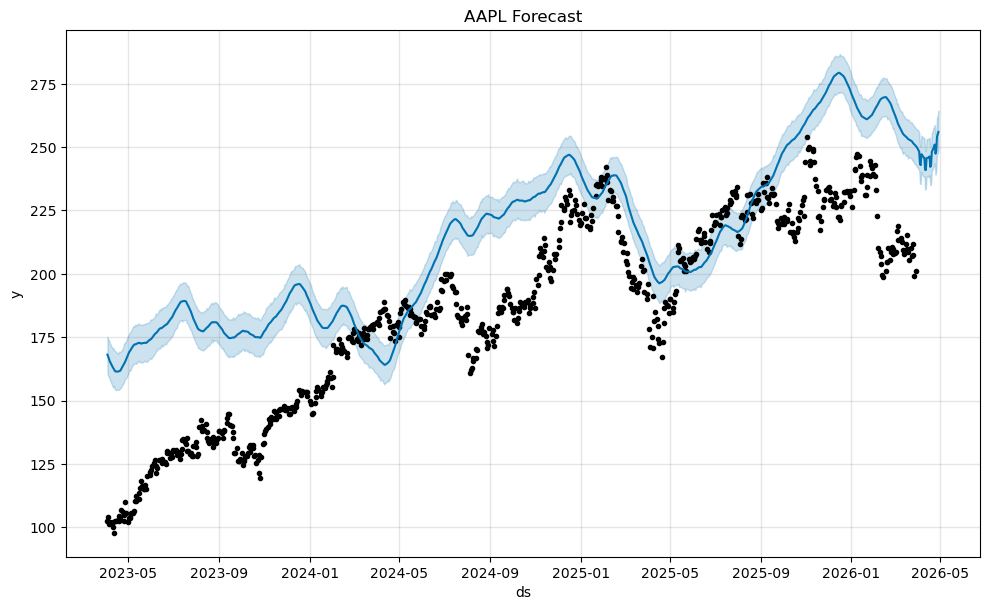

In [54]:
ticker = "AAPL"

model.plot(forecasts[ticker])
plt.title(f"{ticker} Forecast")
plt.show()

In [55]:
# Average predicted return

expected_returns = {}

for ticker in tickers:
    forecast = forecasts[ticker]["yhat"].round(2)
    log_returns = np.log(forecast / forecast.shift(1)).dropna()
    expected_returns[ticker] = log_returns.mean()

expected_returns = pd.Series(expected_returns)
expected_returns

AAPL     0.000540
MSFT     0.000261
GOOGL    0.001324
AMZN     0.000703
dtype: float64

## Portfolio Optimization (Monte Carlo)

In [56]:
n_portfolios = 5000
risk_free_rate = 0.01

results = []

for _ in range(n_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)

    port_return = np.dot(weights, expected_returns)
    port_vol = np.sqrt(weights.T @ cov_matrix @ weights)

    sharpe = (port_return - risk_free_rate) / port_vol

    results.append([port_return, port_vol, sharpe, weights])

results_df = pd.DataFrame(results, columns=["Return", "Volatility", "Sharpe", "Weights"])

In [57]:
best = results_df.iloc[results_df["Sharpe"].idxmax()]

best_weights = dict(zip(tickers, best["Weights"]))

best_weights, best["Sharpe"]

({'AAPL': np.float64(0.007025215801642375),
  'MSFT': np.float64(0.06536327295815476),
  'GOOGL': np.float64(0.011626689164460354),
  'AMZN': np.float64(0.9159848220757425)},
 np.float64(-0.49630394862043553))

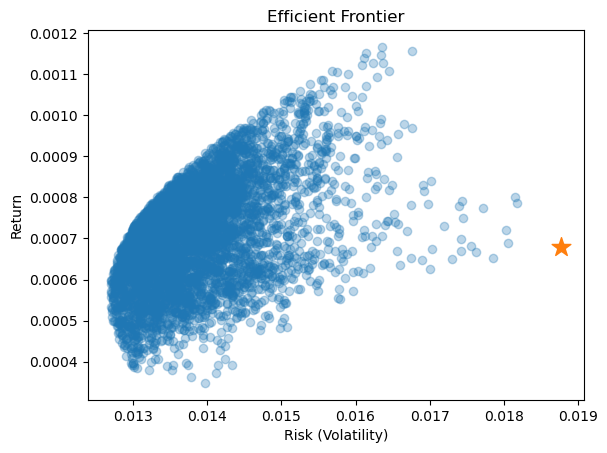

In [58]:
# Efficient Frontier
plt.scatter(results_df["Volatility"], results_df["Return"], alpha=0.3)
plt.scatter(best["Volatility"], best["Return"], marker="*", s=200)

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.show()

### Quant AI Advisor

In [59]:
import google.generativeai as genai
import os
from dotenv import load_dotenv

load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

genai.configure(api_key=GOOGLE_API_KEY)

model = genai.GenerativeModel("gemini-flash-latest")

In [60]:
prompt = f"""
You are a professional portfolio manager.

Respond in this format:

1. Diversification Analysis
2. Risk Assessment
3. Sharpe Ratio Explanation
4. Weaknesses
5. Recommendations

Portfolio:
Weights: {best_weights}
Expected Returns: {expected_returns.to_dict()}
Sharpe: {best['Sharpe']}
Volatility: {best['Volatility']}
"""

response = model.generate_content(prompt)

print(response.text)

As a professional portfolio manager, I have reviewed your current holdings and performance metrics. Here is the portfolio analysis based on the data provided.

### 1. Diversification Analysis
The diversification of this portfolio is **extremely poor**. While the portfolio contains four distinct tickers, it is functionally a single-stock position. 
*   **Concentration Risk:** Amazon (AMZN) accounts for **91.6%** of the total weight. The remaining three assets (AAPL, MSFT, GOOGL) are essentially "rounding errors" that provide no meaningful hedging or diversification.
*   **Sector Homogeneity:** All four assets are U.S. Mega-Cap Technology/Growth stocks. They share high positive correlations, meaning they tend to move in the same direction at the same time. There is zero exposure to other sectors (Healthcare, Financials, Energy), asset classes (Bonds, Commodities), or international markets.

### 2. Risk Assessment
The portfolio carries a high level of **Idiosyncratic Risk**. 
*   **Single

In [61]:
# Forecast Validation

summary = []

for ticker in tickers:
    last_price = data[ticker]["Close"].iloc[-1]
    future_price = forecasts[ticker]["yhat"].iloc[-30:].mean()

    summary.append({
        "Ticker": ticker,
        "Last": last_price,
        "Forecast": future_price,
        "Return": (future_price - last_price)/last_price
    })

summary_df = pd.DataFrame(summary)
summary_df

,Ticker,Last,Forecast,Return
0,AAPL,246.630005,247.324037,0.002814
1,MSFT,358.959991,355.592021,-0.009383
2,GOOGL,273.500000,300.303156,0.098001
3,AMZN,200.949997,189.331273,-0.057819


In [62]:
prompt = f"""
These are predicted returns:

{summary_df.to_dict()}

Are they realistic?
"""

response = model.generate_content(prompt)

print(response.text)

Whether these returns are **"realistic"** depends entirely on the **time horizon** (is this for a day, a month, or a year?) and the **context** of your data.

Here is an analysis of the numbers provided:

### 1. The Time Horizon Problem
*   **If this is a 1-day forecast:** The returns for **GOOGL (+9.8%)** and **AMZN (-5.7%)** are extreme. While they happen (usually during earnings reports), they are statistical outliers for a typical trading day. 
*   **If this is a 1-month forecast:** These are aggressive but possible.
*   **If this is a 1-year forecast:** These returns are actually quite conservative, as the S&P 500 averages ~10% per year.

### 2. Issues with the "Last" Prices
The prices provided in your data do not match current real-world market prices (as of early 2024). This suggests your model might be using old data, synthetic data, or has a data scaling issue:
*   **AAPL at \$246:** Apple has never reached this price (its all-time high is around \$199). 
*   **GOOGL at \$273:

In [63]:
prompt = f"""
Create structured investment report, rank stocks, explain clearly

Forecast Summary:
{summary_df.to_dict()}

Best Portfolio:
{best_weights}

Sharpe Ratio:
{best['Sharpe']}
"""

response = model.generate_content(prompt)

print(response.text)

This investment report provides an analysis of the provided forecast data and portfolio optimization results for a four-stock basket: **Apple (AAPL), Microsoft (MSFT), Alphabet (GOOGL), and Amazon (AMZN).**

---

### **1. Executive Summary**
The model predicts a mixed performance across the selected tech giants. While **Alphabet (GOOGL)** shows the strongest growth potential, the overall portfolio strategy—as currently weighted—carries a **negative Sharpe Ratio (-0.496)**. This indicates that the portfolio’s expected return does not adequately compensate for its risk, and it is currently projected to underperform a risk-free investment (like Treasury bonds).

---

### **2. Stock Rankings (By Forecasted Return)**

Based on the forecasted price changes, the stocks are ranked as follows:

| Rank | Ticker | Expected Return | Current Price | Forecast Price | Outlook |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **1** | **GOOGL** | **+9.80%** | $273.50 | $300.30 | **Strong Bullish** |
| **